# 1. Carregamento das bibliotecas

In [5]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import random
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import json
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
import joblib


from tqdm.notebook import tqdm # para acompanhamento de progresso


Carregamento das funções

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATASET_DIR = Path(
    os.environ.get(
        "ROAD_DATASET_DIR",
        PROJECT_DIR / "data" / "sih_road_dataset",
    )
).expanduser().resolve()
OUTPUT_DIR = Path(
    os.environ.get("ROAD_OUTPUT_DIR", PROJECT_DIR / "outputs")
).expanduser().resolve()


def get_experiment_dir(model_name):
    base = OUTPUT_DIR / model_name
    (base / "plots").mkdir(parents=True, exist_ok=True)
    (base / "models").mkdir(parents=True, exist_ok=True)
    return base


def require_dataset_dir(dataset_dir):
    if not dataset_dir.is_dir():
        raise FileNotFoundError(
            f"Dataset not found at {dataset_dir}. "
            "Place an ImageFolder dataset there or set ROAD_DATASET_DIR."
        )

    class_dirs = [path for path in dataset_dir.iterdir() if path.is_dir()]
    if not class_dirs:
        raise ValueError(
            f"No class directories found in {dataset_dir}. "
            "Expected one directory per class, as required by torchvision.datasets.ImageFolder."
        )

    return dataset_dir


In [6]:
def save_training_curves(train_values, val_values, base_dir, name, seed): # Para salvamento e plotagem das curvas de loss e accuracy

    plot_dir = f'{base_dir}/plots'
    os.makedirs(plot_dir, exist_ok=True)

    plt.figure()
    plt.plot(train_values, label=f'train {name}')
    plt.plot(val_values, label=f'val {name}')
    plt.title(f'{name.capitalize()} per Epoch')
    plt.xlabel('Epoch')
    plt.legend()

    plt.savefig(f'{plot_dir}/{name}_{seed}.png', dpi=300, bbox_inches='tight')

    plt.show()

    plt.close()

In [7]:
def save_metrics_json(
    base_dir,
    model_name,
    best_val_logloss,
    best_val_acc,
    best_epoch,
    acc,
    prec,
    rec,
    f1,
    training_time,
    seed,
):

    os.makedirs(base_dir, exist_ok=True)

    results = {
        "model": model_name,
        "seed": seed,
        "selection_metric": "logloss",

        "best_validation": {
            "val_logloss": best_val_logloss,
            "val_accuracy": best_val_acc,
            "epoch_num": best_epoch
        },

        "test_metrics": {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "training_time": training_time
        }
    }

    path = f'{base_dir}/{model_name}_metrics_{seed}.json'

    with open(path, 'w') as f:
        json.dump(results, f, indent=4)

    print(f"Métricas salvas em: {path}")

In [8]:
def save_confusion_matrix_percent(y_true, y_pred, base_dir, selected_seed):

    plot_dir = f'{base_dir}/plots'
    os.makedirs(plot_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # normalização por linha (porcentagem)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(5,5))

    plt.imshow(
        cm_percent,
        interpolation='nearest',
        cmap='Blues'
    )

    plt.title('Matriz de Confusão (%)')
    plt.colorbar()

    plt.xticks([0, 1], [0, 1])
    plt.yticks([0, 1], [0, 1])

    threshold = cm_percent.max() / 2

    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):

            color = "white" if cm_percent[i, j] > threshold else "black"

            plt.text(
                j,
                i,
                f"{cm_percent[i, j] * 100:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=12,
                fontweight='bold'
            )

    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')

    plt.tight_layout()

    plt.savefig(
        f'{plot_dir}/confusion_matrix_percent_{selected_seed}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

# 2. Carregamento dos dados

In [3]:
require_dataset_dir(DATASET_DIR)
print(f"Dataset: {DATASET_DIR}")
print(f"Outputs: {OUTPUT_DIR}")


FileNotFoundError: Dataset not found at C:\Users\Hanny\Documents\UFU\TCC\experimentos\data\sih_road_dataset. Place an ImageFolder dataset there or set ROAD_DATASET_DIR.

*   Redimensionando imagens para padrão 224x224
*   Transformando para escala de cinza
*   Reestruturando imagens para tensor

In [ ]:
transform = transforms.Compose([ # se adicionar augmentation tem que definir seed
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

path = require_dataset_dir(DATASET_DIR)
dataset = datasets.ImageFolder(root=path, transform=transform)


In [ ]:
print("Classes originais do dataset:")
for idx, class_name in enumerate(dataset.classes):
    print(f"Class {idx}: {class_name}")

Classes originais do dataset:
Class 0: good
Class 1: poor
Class 2: satisfactory
Class 3: very_poor


Redefinição das classes

In [ ]:
macro_map = {}

for idx, class_name in enumerate(dataset.classes):
    base = class_name.lower()

    if base in ["good", "satisfactory"]:
        macro_map[idx] = 0
    elif base in ["poor", "very_poor"]:
        macro_map[idx] = 1


In [ ]:
dataset.targets = [macro_map[label] for label in dataset.targets]

dataset.samples = [
    (path, macro_map[label])
    for path, label in dataset.samples
]

dataset.classes = ["good", "poor"]
dataset.class_to_idx = {
    "good": 0,
    "poor": 1
}

In [ ]:
print(dataset.classes)
print(dataset.class_to_idx)

['good', 'poor']
{'good': 0, 'poor': 1}


In [ ]:
print("Classes transformadas do dataset:")
for idx, class_name in enumerate(dataset.classes):
    print(f"Class {idx}: {class_name}")

Classes transformadas do dataset:
Class 0: good
Class 1: poor


É notável um desbalanceamento, havendo maior representatividade de rodovias em boas condições na base. Sendo assim, optou-se pela aplicação de uma função de perda ponderada para mitigar viés do modelo.

In [ ]:
Counter(dataset.targets)

Counter({0: 1360, 1: 714})

Visualização das imagens

In [ ]:
def show_random_images(dataset, indices, title, n=5):
    samples = random.sample(indices, n)

    plt.figure(figsize=(15, 3))

    for i, idx in enumerate(samples):
        img, label = dataset[idx]

        # tensor → imagem (C,H,W → H,W,C)
        img = img.permute(1, 2, 0)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{title} ({label})")
        plt.axis("off")

    plt.show()

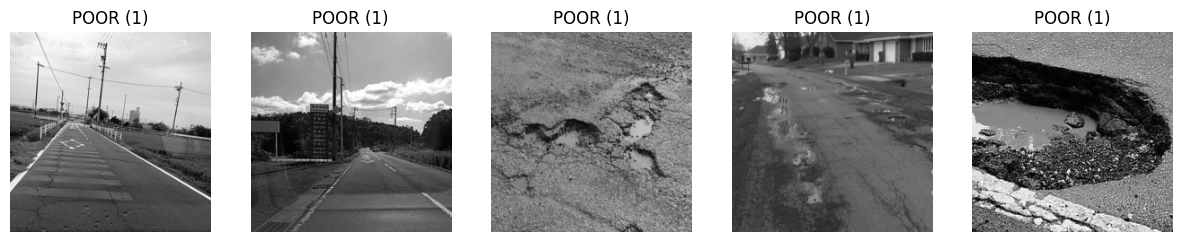

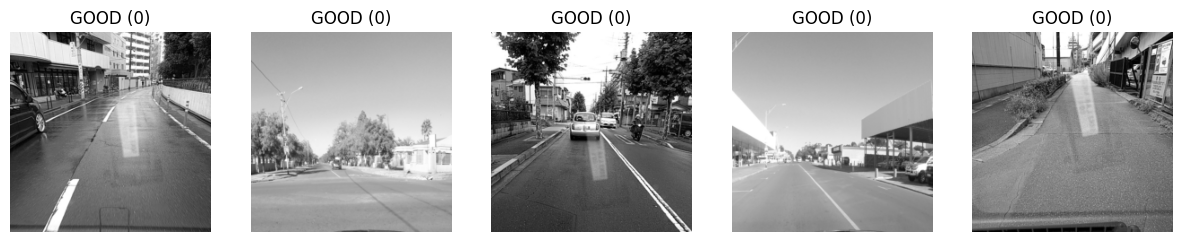

In [ ]:
idx_0 = [i for i, label in enumerate(dataset.targets) if label == 0]
idx_1 = [i for i, label in enumerate(dataset.targets) if label == 1]

show_random_images(dataset, idx_1, "POOR")
show_random_images(dataset, idx_0, "GOOD")

## Variáveis globais


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
pos_weight = torch.tensor([1360 / 714]).to(device) # Função de perda ponderada: maior peso à classe minoritária (rodovias defeituosas)
learning_rate = 0.001

# 3. Divisão da base

In [ ]:
def build_splits_and_loaders(dataset, seed, batch_size=32):
    labels = np.array(dataset.targets)

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=0.7,
        test_size=0.3,
        random_state=seed,
    )
    train_indices, temp_indices = next(splitter.split(np.arange(len(dataset)), labels))

    temp_labels = labels[temp_indices]
    val_test_splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=0.5,
        test_size=0.5,
        random_state=seed,
    )
    val_relative_idx, test_relative_idx = next(
        val_test_splitter.split(np.arange(len(temp_indices)), temp_labels)
    )

    val_indices = temp_indices[val_relative_idx]
    test_indices = temp_indices[test_relative_idx]

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)

    generator = torch.Generator().manual_seed(seed)

    return {
        "train_idx": train_indices,
        "val_idx": val_indices,
        "test_idx": test_indices,
        "train_loader": DataLoader(train_subset, batch_size=batch_size, shuffle=True, generator=generator),
        "val_loader": DataLoader(val_subset, batch_size=batch_size),
        "test_loader": DataLoader(test_subset, batch_size=batch_size),
    }


seeds = [42, 123, 999]
train_idx = {}
val_idx = {}
test_idx = {}
train_loader = {}
val_loader = {}
test_loader = {}

for seed in seeds:
    split = build_splits_and_loaders(dataset, seed)
    train_idx[seed] = split["train_idx"]
    val_idx[seed] = split["val_idx"]
    test_idx[seed] = split["test_idx"]
    train_loader[seed] = split["train_loader"]
    val_loader[seed] = split["val_loader"]
    test_loader[seed] = split["test_loader"]

selected_seed = seeds[0]

print("Divisão da base concluída para as sementes:", seeds)
print("Exemplo de acesso:", f"train_loader[{selected_seed}] ->", type(train_loader[selected_seed]).__name__)


Divisão da base concluída para as sementes: [42, 123, 999]
Exemplo de acesso: train_loader[42] -> DataLoader


# 4. Aplicação dos Algoritmos

## Pipeline CNN's

Funções Auxiliares

In [ ]:
def training_loop(model, criterion, optimizer, train_loader, val_loader, base_dir, selected_seed, log_every=10):

    num_epochs = 10
    best_epoch = 0
    best_val_loss = float('inf')
    best_val_acc = 0.0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_model_path = f'{base_dir}/models/best_model_{selected_seed}.pth'

    start_time = time.time()

    print("=" * 80)
    print(f"[train] Iniciando treino para seed {selected_seed} | epochs={num_epochs}")
    print(f"[train] Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
    print("=" * 80)

    for epoch in range(num_epochs):

        print(f"\n>>> Epoch {epoch+1}/{num_epochs} <<<")

        #  TRAINING ---------------------
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f'Training epoch {epoch+1}')):
            images = images.to(device)
            labels = labels.float().view(-1).to(device)

            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == len(train_loader):
                batch_acc = correct / total
                print(f"  [train] batch {batch_idx+1}/{len(train_loader)} | loss={loss.item():.4f} | acc={batch_acc:.4f}")

        train_acc = correct / total

        #  VALIDATION ----------------------
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_idx, (images, labels) in enumerate(tqdm(val_loader, desc=f'Validation epoch {epoch+1}')):
                images = images.to(device)
                labels = labels.float().view(-1).to(device)

                outputs = model(images).view(-1)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == len(val_loader):
                    batch_acc = correct / total
                    print(f"  [val] batch {batch_idx+1}/{len(val_loader)} | loss={loss.item():.4f} | acc={batch_acc:.4f}")

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)
            print(f"  [best] novo melhor modelo salvo com val_logloss={val_loss:.4f} e val_acc={val_acc:.4f}")

        # metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"  [epoch {epoch+1}] resultado -> train_loss={train_losses[-1]:.4f} | train_acc={train_acc:.4f} | val_loss={val_losses[-1]:.4f} | val_acc={val_acc:.4f}")

    training_time = time.time() - start_time
    print("\n" + "=" * 80)
    print(f"[train] Treinamento concluído | melhor epoch={best_epoch} | best_val_logloss={best_val_loss:.4f} | best_val_acc={best_val_acc:.4f}")
    print(f"[train] Tempo total: {training_time:.2f}s")
    print("=" * 80)

    save_training_curves(train_losses, val_losses, base_dir, "loss", selected_seed)
    save_training_curves(train_accuracies, val_accuracies, base_dir, "accuracy", selected_seed)

    return best_val_loss, best_val_acc, best_epoch, training_time, best_model_path

def evaluate(model, loader, log_every=10):
    model.eval()

    all_preds = []
    all_labels = []

    print("=" * 80)
    print(f"[eval] Iniciando avaliação | batches={len(loader)}")
    print("=" * 80)

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Evaluation")):
            images = images.to(device)
            labels = labels.float().view(-1).to(device)

            outputs = model(images).view(-1)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == len(loader):
                print(f"  [eval] batch {batch_idx+1}/{len(loader)} | amostras processadas={len(all_labels)}")

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"[eval] Métricas finais -> acc={acc:.4f} | precision={prec:.4f} | recall={rec:.4f} | f1={f1:.4f}")

    return acc, prec, rec, f1, all_labels, all_preds

Função do pipeline

In [ ]:
def training_and_evaluation_pipeline(model_factory, model_name, train_loader, val_loader, test_loader, base_dir, selected_seed):

    print("=" * 90)
    print(f"--------------------------- Starting training and evaluation for SEED: {selected_seed} ---------------------------")
    print(f"[pipeline] Model: {model_name}")
    print(f"[pipeline] Device: {device}")
    print(f"[pipeline] Train batches: {len(train_loader[selected_seed])} | Val batches: {len(val_loader[selected_seed])} | Test batches: {len(test_loader[selected_seed])}")
    print("=" * 90)

    print("[pipeline] Iniciando treino...")

    if callable(model_factory):
        model = model_factory(selected_seed)
    else:
        model = model_factory

    criterion = nn.BCEWithLogitsLoss(weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training
    best_val_loss, best_val_acc, best_epoch, training_time, best_model_path = training_loop(
        model,
        criterion,
        optimizer,
        train_loader[selected_seed],
        val_loader[selected_seed],
        base_dir,
        selected_seed
    )

    print("[pipeline] Treinamento concluído. Iniciando avaliação...")

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    model.eval()

    # Evaluation
    acc, prec, rec, f1, y_true, y_pred = evaluate(model, test_loader[selected_seed])

    print("[pipeline] Avaliação concluída.")

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    save_confusion_matrix_percent(y_true, y_pred, base_dir, selected_seed)

    save_metrics_json(
        base_dir,
        model_name,
        best_val_loss,
        best_val_acc,
        best_epoch,
        acc,
        prec,
        rec,
        f1,
        training_time,
        selected_seed
    )

    print("=" * 90)

### a) ResNet18

In [ ]:
model_name = "ResNet18"
base_dir = get_experiment_dir(model_name)
print(f"Base directory: {base_dir}")

Base directory: /content/drive/MyDrive/TCC/experimentos/ResNet18


In [ ]:
def build_resnet18_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

model = build_resnet18_model(42)
model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#### Seed 42

--------------------------- Starting training and evaluation for SEED: 42 ---------------------------
[pipeline] Model: ResNet18
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 42 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.4922 | acc=0.8531
  [train] batch 20/46 | loss=0.9418 | acc=0.8750
  [train] batch 30/46 | loss=0.1721 | acc=0.9021
  [train] batch 40/46 | loss=0.1248 | acc=0.9078
  [train] batch 46/46 | loss=0.1134 | acc=0.9125


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.4935 | acc=0.8714
  [best] novo melhor modelo salvo com val_logloss=0.6259 e val_acc=0.8714
  [epoch 1] resultado -> train_loss=0.4736 | train_acc=0.9125 | val_loss=0.6259 | val_acc=0.8714

>>> Epoch 2/10 <<<


...

  [val] batch 10/10 | loss=0.2686 | acc=0.9228
  [epoch 9] resultado -> train_loss=0.1129 | train_acc=0.9848 | val_loss=0.5016 | val_acc=0.9228

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0523 | acc=0.9812
  [train] batch 20/46 | loss=0.0522 | acc=0.9828
  [train] batch 30/46 | loss=0.0549 | acc=0.9875
  [train] batch 40/46 | loss=0.0920 | acc=0.9844
  [train] batch 46/46 | loss=0.1251 | acc=0.9841


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.3255 | acc=0.9453
  [epoch 10] resultado -> train_loss=0.1126 | train_acc=0.9841 | val_loss=0.3413 | val_acc=0.9453

[train] Treinamento concluído | melhor epoch=8 | best_val_logloss=0.2482 | best_val_acc=0.9453
[train] Tempo total: 631.96s


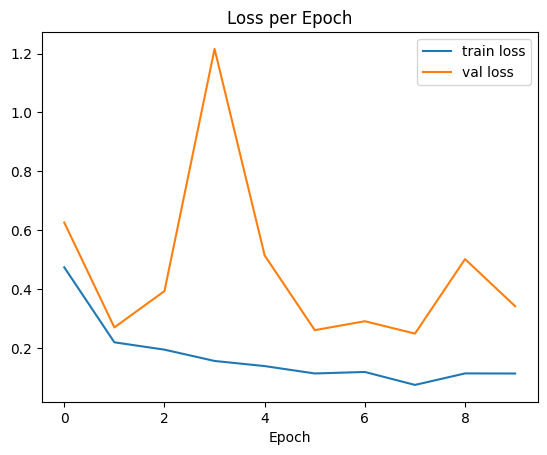

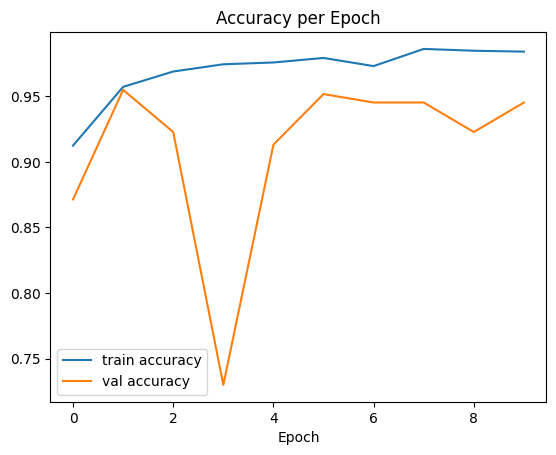

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9231 | precision=0.8320 | recall=0.9720 | f1=0.8966
[pipeline] Avaliação concluída.
Acurácia: 0.9231
Precisão: 0.8320
Recall: 0.9720
F1-score: 0.8966


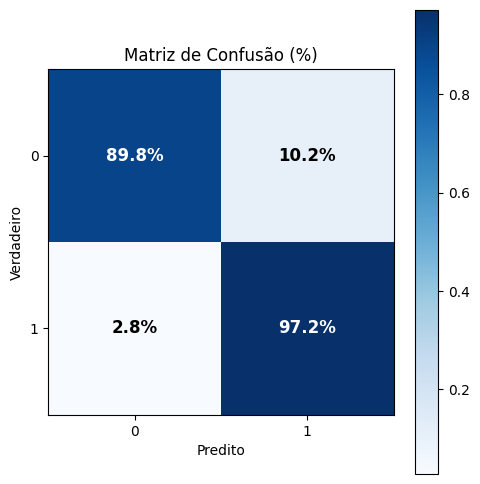

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/ResNet18/ResNet18_metrics_42.json


In [ ]:
training_and_evaluation_pipeline(build_resnet18_model, model_name, train_loader, val_loader, test_loader, base_dir, 42)

#### Seed 123

--------------------------- Starting training and evaluation for SEED: 123 ---------------------------
[pipeline] Model: ResNet18
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 123 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.3901 | acc=0.7719
  [train] batch 20/46 | loss=0.2151 | acc=0.8422
  [train] batch 30/46 | loss=0.2981 | acc=0.8594
  [train] batch 40/46 | loss=0.1779 | acc=0.8789
  [train] batch 46/46 | loss=0.1382 | acc=0.8877


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

...

  [val] batch 10/10 | loss=0.2797 | acc=0.9550
  [epoch 9] resultado -> train_loss=0.0385 | train_acc=0.9931 | val_loss=0.4947 | val_acc=0.9550

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0230 | acc=0.9906
  [train] batch 20/46 | loss=0.3485 | acc=0.9859
  [train] batch 30/46 | loss=0.2575 | acc=0.9823
  [train] batch 40/46 | loss=0.3130 | acc=0.9781
  [train] batch 46/46 | loss=0.1201 | acc=0.9759


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.1341 | acc=0.9389
  [epoch 10] resultado -> train_loss=0.1355 | train_acc=0.9759 | val_loss=0.3939 | val_acc=0.9389

[train] Treinamento concluído | melhor epoch=2 | best_val_logloss=0.2926 | best_val_acc=0.9486
[train] Tempo total: 609.25s


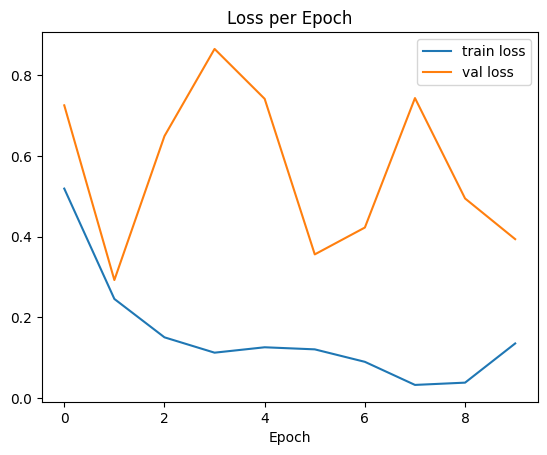

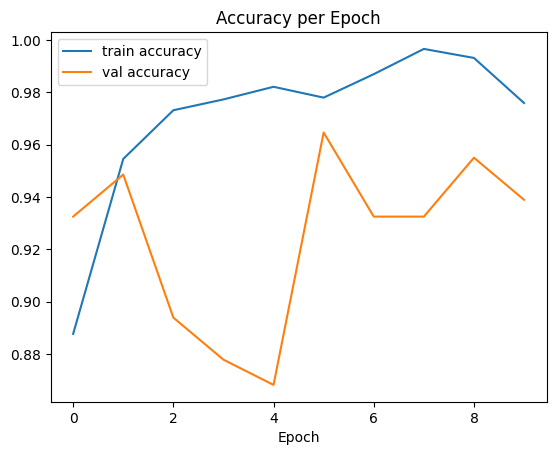

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9615 | precision=0.9798 | recall=0.9065 | f1=0.9417
[pipeline] Avaliação concluída.
Acurácia: 0.9615
Precisão: 0.9798
Recall: 0.9065
F1-score: 0.9417


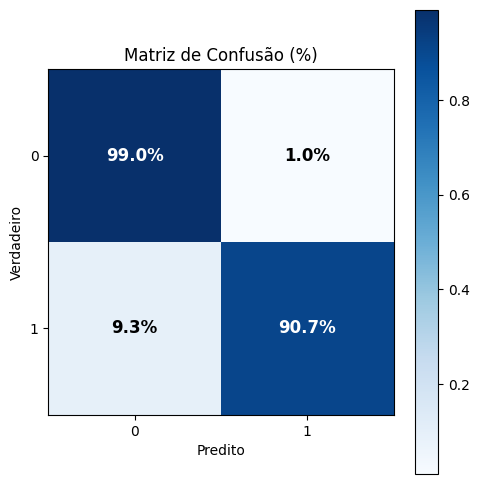

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/ResNet18/ResNet18_metrics_123.json


In [ ]:
training_and_evaluation_pipeline(build_resnet18_model, model_name, train_loader, val_loader, test_loader, base_dir, 123)

#### Seed 999

--------------------------- Starting training and evaluation for SEED: 999 ---------------------------
[pipeline] Model: ResNet18
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 999 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.6827 | acc=0.7844
  [train] batch 20/46 | loss=0.4746 | acc=0.8500
  [train] batch 30/46 | loss=0.2592 | acc=0.8708
  [train] batch 40/46 | loss=0.0774 | acc=0.8938
  [train] batch 46/46 | loss=0.0572 | acc=0.8994


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

...

  [val] batch 10/10 | loss=0.0077 | acc=0.9550
  [epoch 9] resultado -> train_loss=0.1016 | train_acc=0.9793 | val_loss=0.2679 | val_acc=0.9550

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0488 | acc=0.9938
  [train] batch 20/46 | loss=0.0021 | acc=0.9953
  [train] batch 30/46 | loss=0.0071 | acc=0.9865
  [train] batch 40/46 | loss=0.0719 | acc=0.9867
  [train] batch 46/46 | loss=0.2311 | acc=0.9855


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.1044 | acc=0.9132
  [epoch 10] resultado -> train_loss=0.0792 | train_acc=0.9855 | val_loss=0.4279 | val_acc=0.9132

[train] Treinamento concluído | melhor epoch=5 | best_val_logloss=0.2625 | best_val_acc=0.9486
[train] Tempo total: 616.37s


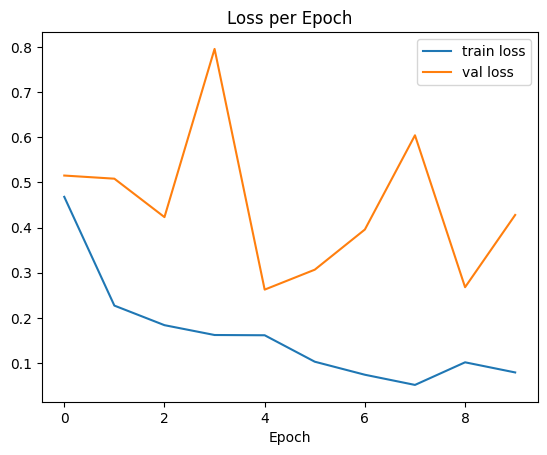

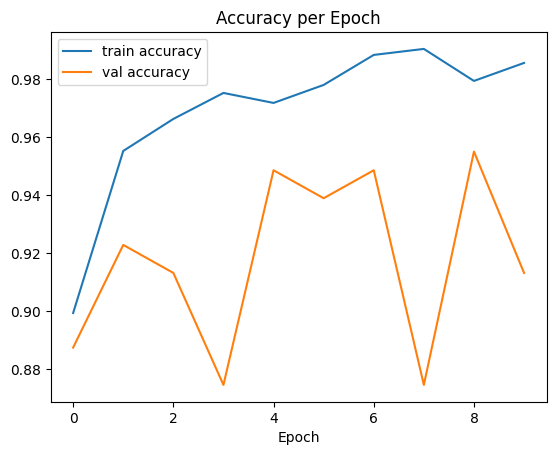

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9583 | precision=0.9700 | recall=0.9065 | f1=0.9372
[pipeline] Avaliação concluída.
Acurácia: 0.9583
Precisão: 0.9700
Recall: 0.9065
F1-score: 0.9372


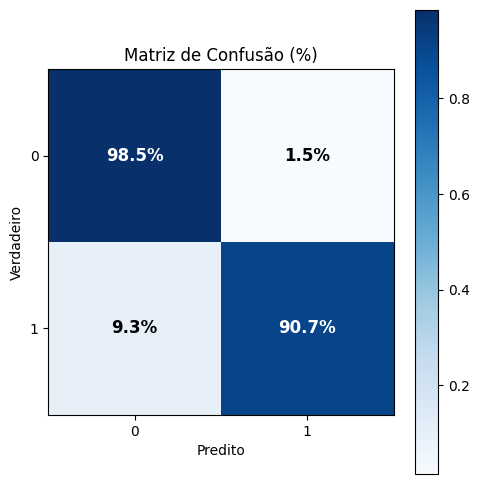

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/ResNet18/ResNet18_metrics_999.json


In [ ]:
training_and_evaluation_pipeline(build_resnet18_model, model_name, train_loader, val_loader, test_loader, base_dir, 999)

### b) EfficientNet

In [ ]:
model_name = "EfficientNet"
base_dir = get_experiment_dir(model_name)
print(f"Base directory: {base_dir}")

Base directory: /content/drive/MyDrive/TCC/experimentos/EfficientNet


In [ ]:
def build_efficientnet_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = models.efficientnet_b0(pretrained=True)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 1)
    return model.to(device)

model = build_efficientnet_model(42)
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#### Seed 42

--------------------------- Starting training and evaluation for SEED: 42 ---------------------------
[pipeline] Model: EfficientNet
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 42 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.2532 | acc=0.8344
  [train] batch 20/46 | loss=0.1102 | acc=0.9016
  [train] batch 30/46 | loss=0.3338 | acc=0.9229
  [train] batch 40/46 | loss=0.4972 | acc=0.9320
  [train] batch 46/46 | loss=0.8576 | acc=0.9290


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.2522 | acc=0.9678
  [best] novo melhor modelo salvo com val_logloss=0.2220 e val_acc=0.9678
  [epoch 1] resultado -> train_loss=0.3751 | train_acc=0.9290 | val_loss=0.2220 | val_acc=0.9678

>>> Epoch 2/10 <<<


...

  [val] batch 10/10 | loss=0.0028 | acc=0.9711
  [epoch 9] resultado -> train_loss=0.0515 | train_acc=0.9904 | val_loss=0.1596 | val_acc=0.9711

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0121 | acc=0.9906
  [train] batch 20/46 | loss=0.3419 | acc=0.9922
  [train] batch 30/46 | loss=0.0056 | acc=0.9938
  [train] batch 40/46 | loss=0.0045 | acc=0.9953
  [train] batch 46/46 | loss=0.0032 | acc=0.9952


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.0079 | acc=0.9775
  [epoch 10] resultado -> train_loss=0.0275 | train_acc=0.9952 | val_loss=0.1770 | val_acc=0.9775

[train] Treinamento concluído | melhor epoch=3 | best_val_logloss=0.1447 | best_val_acc=0.9743
[train] Tempo total: 647.22s


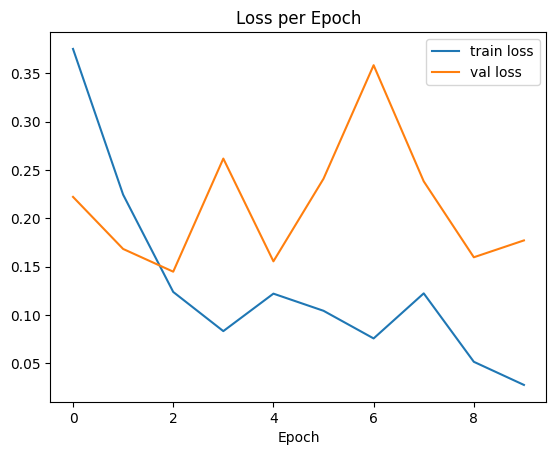

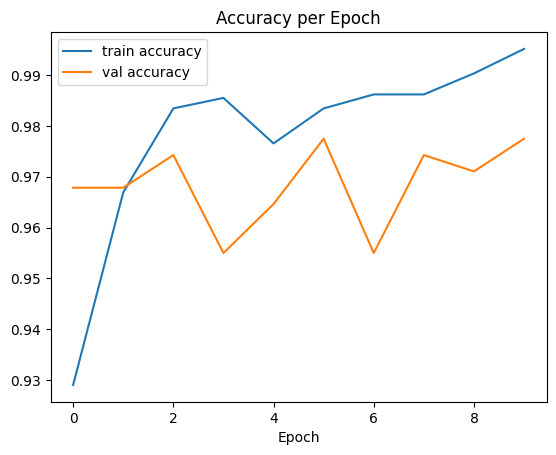

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9776 | precision=0.9545 | recall=0.9813 | f1=0.9677
[pipeline] Avaliação concluída.
Acurácia: 0.9776
Precisão: 0.9545
Recall: 0.9813
F1-score: 0.9677


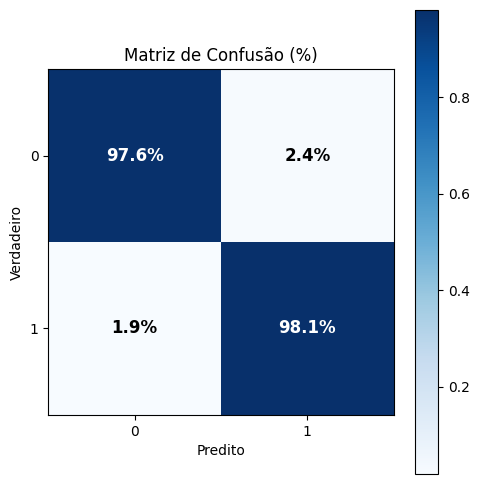

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/EfficientNet/EfficientNet_metrics_42.json


In [ ]:
training_and_evaluation_pipeline(build_efficientnet_model, model_name, train_loader, val_loader, test_loader, base_dir, 42)

#### Seed 123

--------------------------- Starting training and evaluation for SEED: 123 ---------------------------
[pipeline] Model: EfficientNet
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 123 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.2713 | acc=0.8750
  [train] batch 20/46 | loss=0.1797 | acc=0.9062
  [train] batch 30/46 | loss=0.2130 | acc=0.9229
  [train] batch 40/46 | loss=0.0986 | acc=0.9320
  [train] batch 46/46 | loss=0.3820 | acc=0.9345


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

...

  [val] batch 10/10 | loss=0.3377 | acc=0.9614
  [epoch 9] resultado -> train_loss=0.0585 | train_acc=0.9897 | val_loss=0.3415 | val_acc=0.9614

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0176 | acc=0.9906
  [train] batch 20/46 | loss=0.0025 | acc=0.9891
  [train] batch 30/46 | loss=0.0030 | acc=0.9927
  [train] batch 40/46 | loss=0.0037 | acc=0.9930
  [train] batch 46/46 | loss=0.0003 | acc=0.9938


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.3373 | acc=0.9646
  [epoch 10] resultado -> train_loss=0.0277 | train_acc=0.9938 | val_loss=0.3743 | val_acc=0.9646

[train] Treinamento concluído | melhor epoch=6 | best_val_logloss=0.1723 | best_val_acc=0.9743
[train] Tempo total: 640.22s


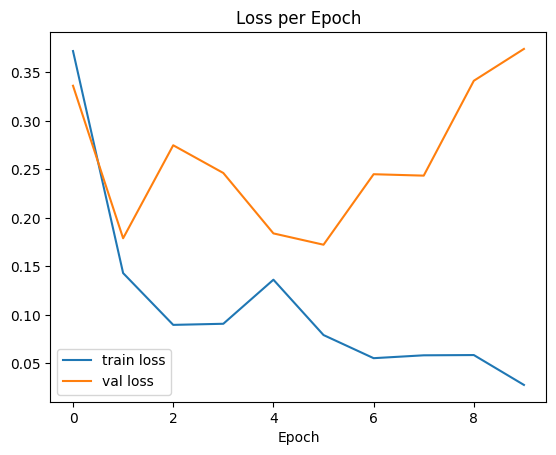

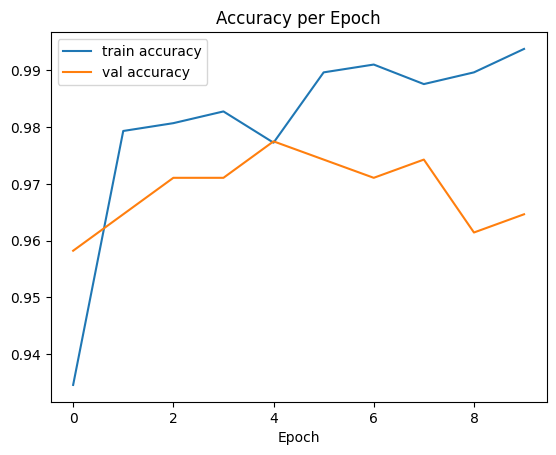

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9776 | precision=0.9902 | recall=0.9439 | f1=0.9665
[pipeline] Avaliação concluída.
Acurácia: 0.9776
Precisão: 0.9902
Recall: 0.9439
F1-score: 0.9665


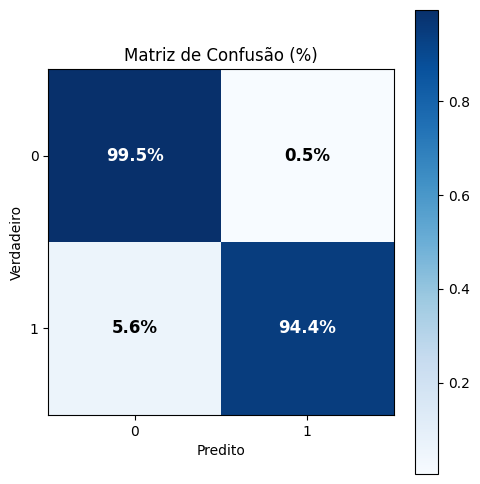

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/EfficientNet/EfficientNet_metrics_123.json


In [ ]:
training_and_evaluation_pipeline(build_efficientnet_model, model_name, train_loader, val_loader, test_loader, base_dir, 123)

#### Seed 999

--------------------------- Starting training and evaluation for SEED: 999 ---------------------------
[pipeline] Model: EfficientNet
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10
[pipeline] Iniciando treino...
[train] Iniciando treino para seed 999 | epochs=10
[train] Train batches: 46 | Val batches: 10

>>> Epoch 1/10 <<<


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.7190 | acc=0.8844
  [train] batch 20/46 | loss=0.2924 | acc=0.9250
  [train] batch 30/46 | loss=0.3173 | acc=0.9292
  [train] batch 40/46 | loss=0.9835 | acc=0.9305
  [train] batch 46/46 | loss=0.1541 | acc=0.9304


Validation epoch 1:   0%|          | 0/10 [00:00<?, ?it/s]

...

  [val] batch 10/10 | loss=0.0013 | acc=0.9775
  [epoch 9] resultado -> train_loss=0.0317 | train_acc=0.9966 | val_loss=0.3081 | val_acc=0.9775

>>> Epoch 10/10 <<<


Training epoch 10:   0%|          | 0/46 [00:00<?, ?it/s]

  [train] batch 10/46 | loss=0.0381 | acc=0.9875
  [train] batch 20/46 | loss=0.0140 | acc=0.9875
  [train] batch 30/46 | loss=0.2603 | acc=0.9885
  [train] batch 40/46 | loss=0.0592 | acc=0.9898
  [train] batch 46/46 | loss=0.0201 | acc=0.9897


Validation epoch 10:   0%|          | 0/10 [00:00<?, ?it/s]

  [val] batch 10/10 | loss=0.0208 | acc=0.9678
  [epoch 10] resultado -> train_loss=0.0577 | train_acc=0.9897 | val_loss=0.2708 | val_acc=0.9678

[train] Treinamento concluído | melhor epoch=2 | best_val_logloss=0.2007 | best_val_acc=0.9678
[train] Tempo total: 638.07s


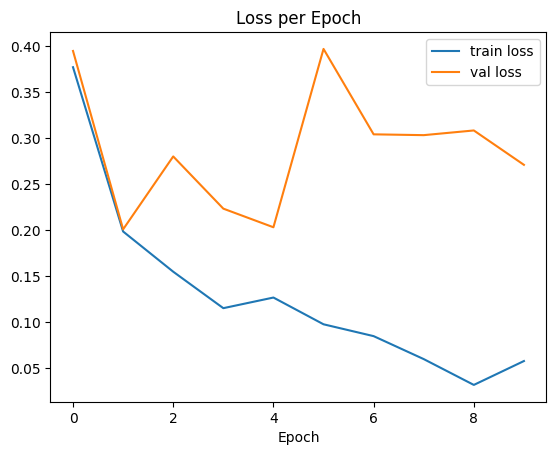

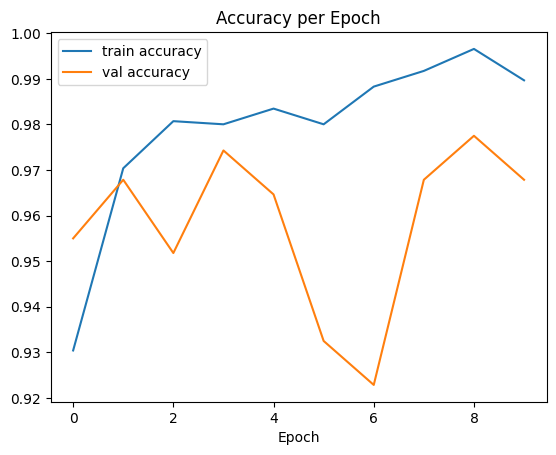

[pipeline] Treinamento concluído. Iniciando avaliação...
[eval] Iniciando avaliação | batches=10


Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

  [eval] batch 10/10 | amostras processadas=312
[eval] Métricas finais -> acc=0.9679 | precision=0.9369 | recall=0.9720 | f1=0.9541
[pipeline] Avaliação concluída.
Acurácia: 0.9679
Precisão: 0.9369
Recall: 0.9720
F1-score: 0.9541


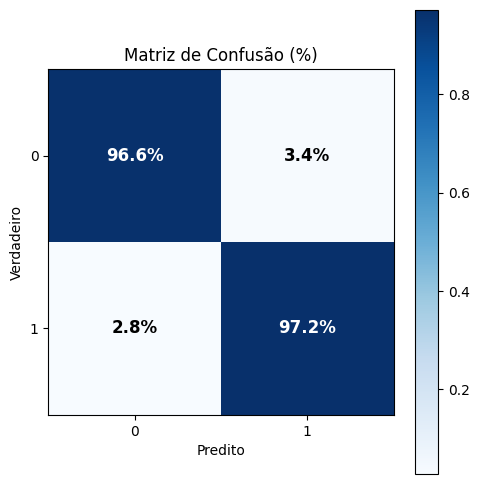

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/EfficientNet/EfficientNet_metrics_999.json


In [ ]:
training_and_evaluation_pipeline(build_efficientnet_model, model_name, train_loader, val_loader, test_loader, base_dir, 999)

## Pipeline VGG16+XGBoost

Funções auxiliares

In [ ]:
def build_vgg16_feature_extractor():
    vgg16 = models.vgg16(pretrained=True)
    vgg16.classifier = nn.Identity()
    vgg16 = vgg16.to(device)
    vgg16.eval()
    return vgg16


def extract_features(feature_extractor, loader):
    features = []
    labels = []

    with torch.no_grad():
        for images, target in tqdm(loader, desc="Extraindo características"):
            images = images.to(device)
            feature = feature_extractor(images)
            features.append(feature.cpu().numpy())
            labels.append(target.numpy())

    return np.concatenate(features), np.concatenate(labels)


def build_xgb_model(selected_seed):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0,
        scale_pos_weight=float(pos_weight),
        use_label_encoder=False,
        early_stopping_rounds=10,
        random_state=selected_seed,
        eval_metric=["error", "logloss"]
    )


def prepare_feature_sets(feature_extractor, train_loader, val_loader, base_dir, selected_seed):
    start_time = time.time()
    X_train, y_train = extract_features(feature_extractor, train_loader[selected_seed])
    extract_time = time.time() - start_time
    print(f"Time - train: {extract_time:.2f}s")

    start_time = time.time()
    X_val, y_val = extract_features(feature_extractor, val_loader[selected_seed])
    extract_time = time.time() - start_time
    print(f"Time - val: {extract_time:.2f}s")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    os.makedirs(base_dir, exist_ok=True)

    np.save(f'{base_dir}/X_train_{selected_seed}.npy', X_train)
    np.save(f'{base_dir}/y_train_{selected_seed}.npy', y_train)
    np.save(f'{base_dir}/X_val_{selected_seed}.npy', X_val)
    np.save(f'{base_dir}/y_val_{selected_seed}.npy', y_val)
    joblib.dump(scaler, f'{base_dir}/scaler_{selected_seed}.pkl')

    print("Features e scaler salvos com sucesso!")

    return X_train, y_train, X_val, y_val, scaler


def train_xgb_model(X_train, y_train, X_val, y_val, selected_seed):
    start_time = time.time()

    xgb_model = build_xgb_model(selected_seed)
    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=True
    )

    training_time = time.time() - start_time
    print(f"Time: {training_time:.2f}s")

    return xgb_model, training_time


def save_xgb_curves(xgb_model, base_dir, selected_seed):
    plot_dir = f'{base_dir}/plots'
    os.makedirs(plot_dir, exist_ok=True)

    results = xgb_model.evals_result()

    train_loss = results['validation_0']['logloss']
    train_acc = [1 - e for e in results['validation_0']['error']]
    val_loss = results['validation_1']['logloss']
    val_acc = [1 - e for e in results['validation_1']['error']]

    name = "loss"
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train')
    plt.plot(val_loss, label='Validation')
    plt.xlabel('Boosting rounds')
    plt.ylabel('Log Loss')
    plt.title('Loss de treino e validação')
    plt.legend()
    plt.savefig(f'{plot_dir}/{name}_{selected_seed}.png', dpi=300, bbox_inches='tight')
    plt.close()

    name = "accuracy"
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc, label='Train')
    plt.plot(val_acc, label='Validation')
    plt.xlabel('Boosting rounds')
    plt.ylabel('Acurácia')
    plt.title('Acurácia de treino e validação')
    plt.legend()
    plt.savefig(f'{plot_dir}/{name}_{selected_seed}.png', dpi=300, bbox_inches='tight')
    plt.close()


Função do pipeline

In [ ]:
def training_and_evaluation_pipeline_vgg_xgb(feature_extractor, model_name, train_loader, val_loader, test_loader, base_dir, selected_seed):
    print("=" * 90)
    print(f"--------------------------- Starting training and evaluation for SEED: {selected_seed} ---------------------------")
    print(f"[pipeline] Model: {model_name}")
    print(f"[pipeline] Device: {device}")
    print(f"[pipeline] Train batches: {len(train_loader[selected_seed])} | Val batches: {len(val_loader[selected_seed])} | Test batches: {len(test_loader[selected_seed])}")
    print("=" * 90)

    X_train, y_train, X_val, y_val, scaler = prepare_feature_sets(
        feature_extractor,
        train_loader,
        val_loader,
        base_dir,
        selected_seed,
    )

    xgb_model, training_time = train_xgb_model(X_train, y_train, X_val, y_val, selected_seed)
    save_xgb_curves(xgb_model, base_dir, selected_seed)
    xgb_model.save_model(f'{base_dir}/models/xgb_model_{selected_seed}.json')

    evals_result = {}
    try:
        evals_result = xgb_model.evals_result()
    except Exception as exc:
        print(f"[pipeline] Aviso: não foi possível recuperar evals_result: {exc}")

    val_logloss = []
    if "validation_1" in evals_result and "logloss" in evals_result["validation_1"]:
        val_logloss = evals_result["validation_1"]["logloss"]

    best_round = len(val_logloss)
    if hasattr(xgb_model, 'best_iteration') and xgb_model.best_iteration is not None:
        best_round = int(xgb_model.best_iteration)

    best_val_logloss = val_logloss[best_round - 1] if best_round > 0 and len(val_logloss) >= best_round else float('inf')

    reloaded_xgb_model = build_xgb_model(selected_seed)
    reloaded_xgb_model.load_model(f'{base_dir}/models/xgb_model_{selected_seed}.json')

    y_pred = reloaded_xgb_model.predict(X_val)
    print(classification_report(y_val, y_pred, target_names=['Classe 0', 'Classe 1']))

    X_test, y_test = extract_features(feature_extractor, test_loader[selected_seed])
    X_test = scaler.transform(X_test)

    y_test_pred = reloaded_xgb_model.predict(X_test)
    print(classification_report(y_test, y_test_pred, target_names=['Classe 0', 'Classe 1']))

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    save_confusion_matrix_percent(y_test, y_test_pred, base_dir, selected_seed)

    y_pred_val = reloaded_xgb_model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred_val)

    save_metrics_json(
        base_dir,
        model_name,
        best_val_logloss,
        val_acc,
        best_round,
        acc,
        prec,
        rec,
        f1,
        training_time,
        selected_seed,
    )

    print("=" * 90)

In [ ]:

model_name = "VGG16+XGBoost"
base_dir = get_experiment_dir(model_name)
print(base_dir)

feature_extractor = build_vgg16_feature_extractor()


/content/drive/MyDrive/TCC/experimentos/VGG16+XGBoost


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.9MB/s]


### Seed 42

--------------------------- Starting training and evaluation for SEED: 42 ---------------------------
[pipeline] Model: VGG16+XGBoost
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10


Extraindo características:   0%|          | 0/46 [00:00<?, ?it/s]

Time - train: 54.25s


Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

Time - val: 11.52s
Features e scaler salvos com sucesso!


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [00:09:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-error:0.03032	validation_0-logloss:0.47066	validation_1-error:0.12540	validation_1-logloss:0.52069
[1]	validation_0-error:0.01930	validation_0-logloss:0.33583	validation_1-error:0.10611	validation_1-logloss:0.41658
[2]	validation_0-error:0.00758	validation_0-logloss:0.24849	validation_1-error:0.07395	validation_1-logloss:0.34114
[3]	validation_0-error:0.00551	validation_0-logloss:0.18538	validation_1-error:0.07395	validation_1-logloss:0.28837
[4]	validation_0-error:0.00276	validation_0-logloss:0.14085	validation_1-error:0.06109	validation_1-logloss:0.25130
[5]	validation_0-error:0.00138	validation_0-logloss:0.11015	validation_1-error:0.06109	validation_1-logloss:0.22579
[6]	validation_0-error:0.00138	validation_0-logloss:0.08661	validation_1-error:0.05466	validation_1-logloss:0.20952
[7]	validation_0-error:0.00138	validation_0-logloss:0.06904	validation_1-error:0.05145	validation_1-logloss:0.19300
[8]	validation_0-error:0.00138	validation_0-logloss:0.05549	validation_1

Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Classe 0       0.97      0.98      0.97       205
    Classe 1       0.95      0.93      0.94       107

    accuracy                           0.96       312
   macro avg       0.96      0.96      0.96       312
weighted avg       0.96      0.96      0.96       312

Acurácia: 0.9615
Precisão: 0.9524
Recall: 0.9346
F1-score: 0.9434


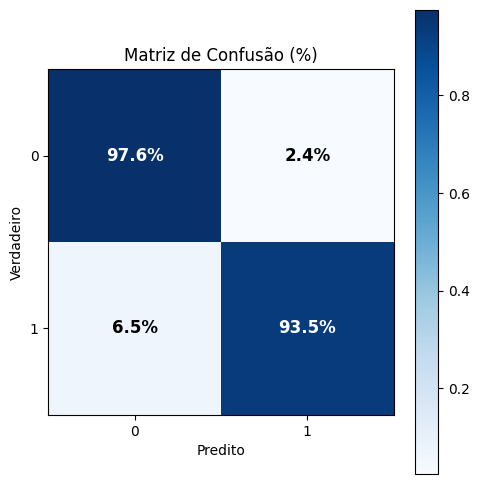

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/VGG16+XGBoost/VGG16+XGBoost_metrics_42.json


In [ ]:
training_and_evaluation_pipeline_vgg_xgb(feature_extractor, model_name, train_loader, val_loader, test_loader, base_dir, 42)


### Seed 123

--------------------------- Starting training and evaluation for SEED: 123 ---------------------------
[pipeline] Model: VGG16+XGBoost
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10


Extraindo características:   0%|          | 0/46 [00:00<?, ?it/s]

Time - train: 53.89s


Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

Time - val: 9.97s
Features e scaler salvos com sucesso!


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [00:12:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-error:0.03032	validation_0-logloss:0.47369	validation_1-error:0.10932	validation_1-logloss:0.51795
[1]	validation_0-error:0.02412	validation_0-logloss:0.33420	validation_1-error:0.10611	validation_1-logloss:0.41140
[2]	validation_0-error:0.00414	validation_0-logloss:0.24696	validation_1-error:0.09646	validation_1-logloss:0.34939
[3]	validation_0-error:0.00482	validation_0-logloss:0.18622	validation_1-error:0.08039	validation_1-logloss:0.29576
[4]	validation_0-error:0.00207	validation_0-logloss:0.14110	validation_1-error:0.08039	validation_1-logloss:0.25869
[5]	validation_0-error:0.00207	validation_0-logloss:0.10931	validation_1-error:0.07074	validation_1-logloss:0.23985
[6]	validation_0-error:0.00138	validation_0-logloss:0.08569	validation_1-error:0.06752	validation_1-logloss:0.21680
[7]	validation_0-error:0.00000	validation_0-logloss:0.06760	validation_1-error:0.05145	validation_1-logloss:0.20107
[8]	validation_0-error:0.00000	validation_0-logloss:0.05398	validation_1

Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Classe 0       0.97      0.98      0.97       205
    Classe 1       0.95      0.93      0.94       107

    accuracy                           0.96       312
   macro avg       0.96      0.96      0.96       312
weighted avg       0.96      0.96      0.96       312

Acurácia: 0.9615
Precisão: 0.9524
Recall: 0.9346
F1-score: 0.9434


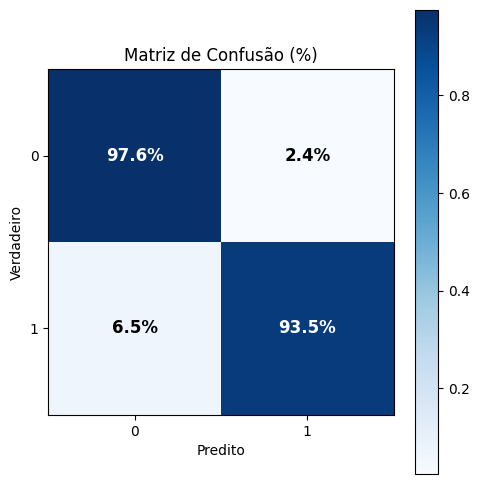

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/VGG16+XGBoost/VGG16+XGBoost_metrics_123.json


In [ ]:
training_and_evaluation_pipeline_vgg_xgb(feature_extractor, model_name, train_loader, val_loader, test_loader, base_dir, 123)

### Seed 999

--------------------------- Starting training and evaluation for SEED: 999 ---------------------------
[pipeline] Model: VGG16+XGBoost
[pipeline] Device: cuda:0
[pipeline] Train batches: 46 | Val batches: 10 | Test batches: 10


Extraindo características:   0%|          | 0/46 [00:00<?, ?it/s]

Time - train: 52.82s


Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

Time - val: 11.44s
Features e scaler salvos com sucesso!


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [00:15:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-error:0.03308	validation_0-logloss:0.47344	validation_1-error:0.13183	validation_1-logloss:0.52140
[1]	validation_0-error:0.02481	validation_0-logloss:0.33828	validation_1-error:0.12540	validation_1-logloss:0.41923
[2]	validation_0-error:0.01103	validation_0-logloss:0.24914	validation_1-error:0.09325	validation_1-logloss:0.34867
[3]	validation_0-error:0.01172	validation_0-logloss:0.18843	validation_1-error:0.08682	validation_1-logloss:0.29721
[4]	validation_0-error:0.00414	validation_0-logloss:0.14506	validation_1-error:0.08360	validation_1-logloss:0.25796
[5]	validation_0-error:0.00345	validation_0-logloss:0.11159	validation_1-error:0.06431	validation_1-logloss:0.22426
[6]	validation_0-error:0.00276	validation_0-logloss:0.08804	validation_1-error:0.06109	validation_1-logloss:0.20146
[7]	validation_0-error:0.00276	validation_0-logloss:0.07051	validation_1-error:0.06109	validation_1-logloss:0.18543
[8]	validation_0-error:0.00207	validation_0-logloss:0.05688	validation_1

Extraindo características:   0%|          | 0/10 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Classe 0       0.97      0.97      0.97       205
    Classe 1       0.94      0.93      0.94       107

    accuracy                           0.96       312
   macro avg       0.95      0.95      0.95       312
weighted avg       0.96      0.96      0.96       312

Acurácia: 0.9583
Precisão: 0.9434
Recall: 0.9346
F1-score: 0.9390


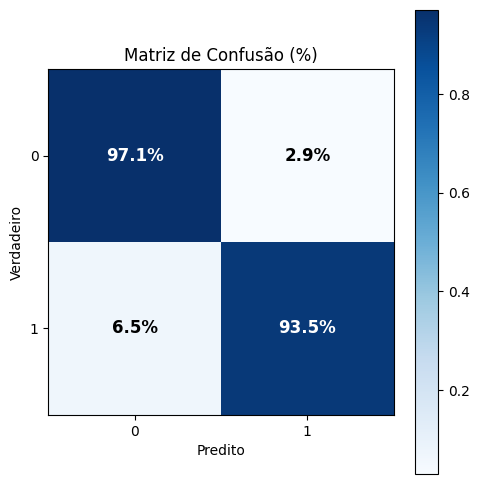

Métricas salvas em: /content/drive/MyDrive/TCC/experimentos/VGG16+XGBoost/VGG16+XGBoost_metrics_999.json


In [ ]:
training_and_evaluation_pipeline_vgg_xgb(feature_extractor,  model_name, train_loader, val_loader, test_loader, base_dir, 999)